# Análisis Exploratorio de Datos (EDA): Inseguridad y Economía en Perú
**Autor:** Yomel Jair Barreto Flores  
**Descripción:** Este notebook realiza un análisis profundo de la relación entre la criminalidad y variables económicas (desempleo e inflación) a nivel nacional, utilizando datos procesados en BigQuery.

In [14]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import bigquery
from google.oauth2 import service_account
from scipy import stats


KEY_PATH = '../auth/key.json' 
PROJECT_ID = 'my-project-big-data-484021' 
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)
client = bigquery.Client(credentials=credentials, project=PROJECT_ID)

query = "SELECT * FROM `analytics_data.master_analytics`"
df = client.query(query).to_dataframe()

print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset cargado con 344797 filas y 10 columnas.


# 0. Marco Conceptual y Planteamiento de Hipótesis

Antes de proceder con el análisis técnico, definimos el marco teórico que guía esta investigación sobre la seguridad ciudadana en el Perú.

### Pregunta de Investigación
¿Existe una relación estadísticamente significativa entre las variaciones del costo de vida (IPC) y la falta de empleo con la incidencia delictiva nacional?

### Hipótesis de Trabajo ($H_a$)
* **$H_{a1}$:** El incremento de la inflación (IPC) tiene una correlación positiva fuerte con la criminalidad, debido a la presión económica sobre los hogares.
* **$H_{a2}$:** El aumento de la tasa de desempleo actúa como un catalizador del delito, existiendo una relación directa entre ambas variables.

### Hipótesis Nula ($H_0$)
* **$H_0$:** No existe relación lineal significativa entre los indicadores económicos y las denuncias policiales ($r = 0$).

---

## 1. Inspección General de la Calidad de Datos
Antes de realizar inferencias, verificamos la integridad del dataset: tipos de datos, presencia de nulos y estadísticas descriptivas básicas.

In [15]:
print("--- Información del Dataset ---")
print(df.info())

print(f"\nDuplicados encontrados: {df.duplicated().sum()}")

df.describe().T

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344797 entries, 0 to 344796
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fecha              344797 non-null  dbdate 
 1   departamento       344797 non-null  object 
 2   provincia          344797 non-null  object 
 3   distrito           344797 non-null  object 
 4   modalidad          344797 non-null  object 
 5   nro_denuncias      344797 non-null  Int64  
 6   poblacion_total    344797 non-null  Int64  
 7   tasa_criminalidad  344797 non-null  float64
 8   tasa_desempleo     344797 non-null  float64
 9   indice_precios     344797 non-null  float64
dtypes: Int64(2), dbdate(1), float64(3), object(4)
memory usage: 27.0+ MB
None

Duplicados encontrados: 0


,count,mean,std,min,25%,50%,75%,max
nro_denuncias,344797.0,19.83566,57.192591,1.0,1.0,3.0,12.0,1303.0
poblacion_total,344797.0,44755.28823,97027.661166,185.0,5818.0,13829.0,39490.0,1160109.0
tasa_criminalidad,344797.0,5.720774,7.479115,0.00862,1.408054,3.519887,7.377352,421.686747
tasa_desempleo,344797.0,7.996768,2.871773,4.989175,6.223106,7.068077,8.15791,16.53163
indice_precios,344797.0,103.120837,9.76133,88.594649,93.014206,103.211072,113.591104,115.9233


In [16]:
# Buscamos la fila con la tasa máxima para auditarla
outlier_row = df.loc[df['tasa_criminalidad'].idxmax()]

print(f"Departamento: {outlier_row['departamento']}")
print(f"Provincia:    {outlier_row['provincia']}")
print(f"Distrito:     {outlier_row['distrito']}")
print(f"Modalidad:    {outlier_row['modalidad']}")
print(f"Denuncias:    {outlier_row['nro_denuncias']}")
print(f"Población:    {outlier_row['poblacion_total']}")
print(f"Tasa:         {outlier_row['tasa_criminalidad']}")

Departamento: MOQUEGUA
Provincia:    ILO
Distrito:     EL ALGARROBAL
Modalidad:    OTROS
Denuncias:    14
Población:    332
Tasa:         421.6867469879518


## 2. Limpieza de Texto y Estandarización
En la vista previa de BigQuery notamos caracteres extraños (ej. `EXTORSIÃ³N`). Es importante limpiar las categorías de `modalidad` para que los filtros y agrupaciones sean precisos.

In [ ]:
df['modalidad'] = df['modalidad'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
df['modalidad'] = df['modalidad'].str.upper().str.strip()

mapeo_modalidades = {
    'EXTORSIA3N': 'EXTORSION',
    'VIOLENCIA CONTRA LA MUJER E INTEGRANTES': 'VIOLENCIA FAMILIAR' 
}
df['modalidad'] = df['modalidad'].replace(mapeo_modalidades)

df['fecha'] = pd.to_datetime(df['fecha'])


print(df.info())

print("--- Modalidades de Crimen ---")
print(df['modalidad'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344797 entries, 0 to 344796
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   fecha              344797 non-null  datetime64[ns]
 1   departamento       344797 non-null  object        
 2   provincia          344797 non-null  object        
 3   distrito           344797 non-null  object        
 4   modalidad          344797 non-null  object        
 5   nro_denuncias      344797 non-null  Int64         
 6   poblacion_total    344797 non-null  Int64         
 7   tasa_criminalidad  344797 non-null  float64       
 8   tasa_desempleo     344797 non-null  float64       
 9   indice_precios     344797 non-null  float64       
dtypes: Int64(2), datetime64[ns](1), float64(3), object(4)
memory usage: 27.0+ MB
None
--- Modalidades de Crimen Detectadas ---
['EXTORSION' 'HOMICIDIO' 'ROBO' 'ESTAFA' 'HURTO' 'OTROS'
 'VIOLENCIA FAMILIAR']


## 3. Agregación Nacional Mensual
Para analizar la correlación con indicadores macroeconómicos (IPC, Desempleo), debemos colapsar la granularidad distrital en una serie de tiempo nacional.

In [18]:
df_nacional = df.groupby('fecha').agg({
    'nro_denuncias': 'sum',
    'tasa_desempleo': 'mean',
    'indice_precios': 'mean'
}).reset_index()

pob_total_aprox = df['poblacion_total'].unique().sum()
df_nacional['tasa_criminalidad_nac'] = (df_nacional['nro_denuncias'] / pob_total_aprox) * 10000

print(f"Serie de tiempo generada con {len(df_nacional)} meses de datos.")
df_nacional.head()

Serie de tiempo generada con 96 meses de datos.


,fecha,nro_denuncias,tasa_desempleo,indice_precios,tasa_criminalidad_nac
0,2018-01-01,60106,7.300441,88.594649,18.792564
1,2018-02-01,59098,8.027418,88.816331,18.477405
2,2018-03-01,66438,8.061365,89.248976,20.772308
3,2018-04-01,63857,7.324525,89.126640,19.96534
4,2018-05-01,63562,6.636802,89.143089,19.873106


## 4. Visualización de Tendencias Nacionales
Graficamos la evolución temporal de las denuncias frente a los indicadores económicos para identificar patrones visuales antes de aplicar pruebas de correlación.

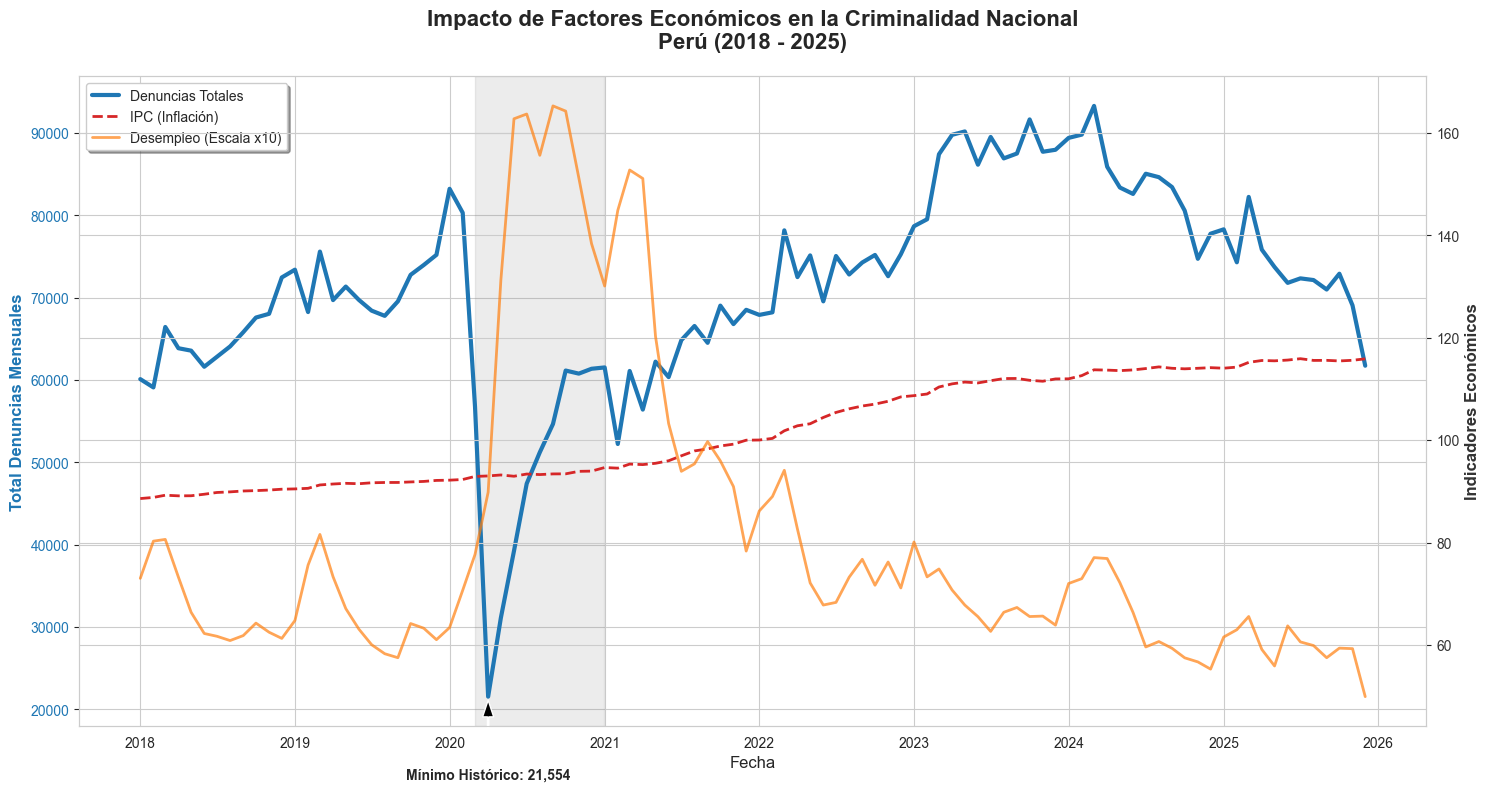

In [ ]:
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(15, 8))

color_denuncias = '#1f77b4' 
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Total Denuncias Mensuales', color=color_denuncias, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_nacional['fecha'], df_nacional['nro_denuncias'], 
                 color=color_denuncias, linewidth=3, label='Denuncias Totales')
ax1.tick_params(axis='y', labelcolor=color_denuncias)

ax2 = ax1.twinx()
color_ipc = '#d62728' 
color_des = '#ff7f0e'

ax2.set_ylabel('Indicadores Económicos', color='#333333', fontsize=12, fontweight='bold')
line2 = ax2.plot(df_nacional['fecha'], df_nacional['indice_precios'], 
                 color=color_ipc, linestyle='--', linewidth=2, label='IPC (Inflación)')
line3 = ax2.plot(df_nacional['fecha'], df_nacional['tasa_desempleo'] * 10, 
                 color=color_des, alpha=0.7, linewidth=2, label='Desempleo (Escala x10)')
ax2.tick_params(axis='y', labelcolor='#333333')


ax1.axvspan('2020-03-01', '2020-12-31', color='gray', alpha=0.15, label='Periodo Cuarentena')

min_denuncias = df_nacional['nro_denuncias'].min()
fecha_min = df_nacional.loc[df_nacional['nro_denuncias'].idxmin(), 'fecha']
ax1.annotate(f'Mínimo Histórico: {min_denuncias:,.0f}', 
             xy=(fecha_min, min_denuncias), xytext=(fecha_min, min_denuncias-10000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold', ha='center')

plt.title('Impacto de Factores Económicos en la Criminalidad Nacional\nPerú (2018 - 2025)', 
          fontsize=16, fontweight='bold', pad=20)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)

fig.tight_layout()
plt.savefig('../reports/01_tendencia_nacional_pro.png', dpi=300)
plt.show()

## 5. Análisis de Correlación Estadística (Pearson)
Calculamos el Coeficiente de Correlación de Pearson ($r$) para cuantificar la fuerza de la relación lineal entre la criminalidad y los indicadores económicos, evaluando su significancia estadística ($p-value$).

In [20]:
r_ipc, p_ipc = stats.pearsonr(df_nacional['nro_denuncias'], df_nacional['indice_precios'])

r_des, p_des = stats.pearsonr(df_nacional['nro_denuncias'], df_nacional['tasa_desempleo'])

print(f"--- Análisis Nacional (96 meses) ---")
print(f"Correlación Crimen-Inflación:  r = {r_ipc:.4f}, p-value = {p_ipc:.4e}")
print(f"Correlación Crimen-Desempleo:  r = {r_des:.4f}, p-value = {p_des:.4e}")

--- Análisis Nacional (96 meses) ---
Correlación Crimen-Inflación:  r = 0.6157, p-value = 2.4541e-11
Correlación Crimen-Desempleo:  r = -0.5888, p-value = 2.8070e-10


Tras procesar 96 meses de datos agregados, se observan dos fenómenos distintos:

1. **Efecto Inflación:** Existe una correlación positiva moderada-fuerte ($r = 0.61$) con una significancia estadística alta. Esto sugiere que el costo de vida es un predictor relevante de la criminalidad a nivel macro.
2. **Paradoja del Desempleo:** Se observa una correlación negativa ($r = -0.58$), la cual es contraintuitiva. Este fenómeno se explica por la anomalía del año 2020 (Pandemia de COVID-19), donde el desempleo alcanzó máximos históricos mientras que el confinamiento redujo drásticamente las oportunidades de delito.

**Conclusión técnica:** Es necesario realizar una prueba de correlación excluyendo el periodo de confinamiento para observar la relación en condiciones económicas normales.

## 6. Análisis de Sensibilidad: Exclusión del Periodo Anómalo (2020)
Para validar si la correlación negativa entre desempleo y criminalidad es producto del sesgo por el confinamiento, procedemos a filtrar el año 2020 y recalcular los coeficientes en condiciones de movilidad normal.

In [21]:
df_sensibilidad = df_nacional[df_nacional['fecha'].dt.year != 2020].copy()

r_ipc_s, p_ipc_s = stats.pearsonr(df_sensibilidad['nro_denuncias'], df_sensibilidad['indice_precios'])
r_des_s, p_des_s = stats.pearsonr(df_sensibilidad['nro_denuncias'], df_sensibilidad['tasa_desempleo'])

print(f"--- Análisis de Sensibilidad (Sin 2020) ---")
print(f"Correlación Crimen-Inflación:  r = {r_ipc_s:.4f}, p-value = {p_ipc_s:.4e}")
print(f"Correlación Crimen-Desempleo:  r = {r_des_s:.4f}, p-value = {p_des_s:.4e}")

--- Análisis de Sensibilidad (Sin 2020) ---
Correlación Crimen-Inflación:  r = 0.6734, p-value = 2.2393e-12
Correlación Crimen-Desempleo:  r = -0.4349, p-value = 3.5722e-05


## 7. Síntesis y Conclusiones del Análisis de Correlación

Tras realizar el análisis global y la prueba de sensibilidad, se consolidan los siguientes hallazgos:

### Comparativa de Coeficientes ($r$ de Pearson)
| Variable | Escenario Global (Incluye 2020) | Escenario Normalizado (Sin 2020) | Cambio en la Fuerza |
| :--- | :---: | :---: | :--- |
| **Inflación (IPC)** | 0.6157 | **0.6734** | 🟢 Incremento (Relación más robusta) |
| **Desempleo** | -0.5888 | **-0.4349** | 🟡 Reducción (Menos sesgo, pero persiste) |

### Interpretación Estadística Final y Validación de Hipótesis

Tras el análisis de los datos nacionales (2018-2025), procedemos a contrastar los resultados con las hipótesis iniciales:

1. **Validación de $H_{a1}$ (Inflación): ACEPTADA**
   * Se observa una correlación positiva y fuerte ($r = 0.67$) con una significancia estadística concluyente ($p < 0.05$). 
   * **Conclusión:** La inflación es el predictor más estable de la criminalidad. El aumento en el costo de vida presiona la estructura social, validando que el factor económico es un motor directo del delito en el Perú.

2. **Validación de $H_{a2}$ (Desempleo): RECHAZADA (Relación Inversa)**
   * Aunque el resultado es estadísticamente significativo ($p < 0.05$), la correlación es negativa ($r = -0.43$), lo cual contradice la hipótesis inicial de una relación directa.
   * **Hallazgo:** El desempleo oficial no actúa como catalizador del delito de la forma esperada. Esto sugiere que en una economía con alta **informalidad**, la falta de empleo formal no es el detonante principal, sino la precariedad del ingreso (capturada mejor por el IPC).

3. **Decisión sobre la Hipótesis Nula ($H_0$): RECHAZADA**
   * Dado que en ambos casos el $p-value$ es menor a 0.05, se rechaza la hipótesis de que no existe relación entre las variables. Existe una conexión real entre la economía y el crimen, aunque la naturaleza de la relación con el desempleo requiere modelos de estudio más complejos (subempleo/informalidad).

---

## 8. Visualización de Regresión Lineal (Scatter Plot)
Para culminar el análisis, proyectamos la dispersión de los datos nacionales frente a una línea de regresión lineal, excluyendo el periodo anómalo de 2020. Esto permite visualizar no solo la fuerza de la relación ($r$), sino también la consistencia y el ajuste del modelo de tendencia.

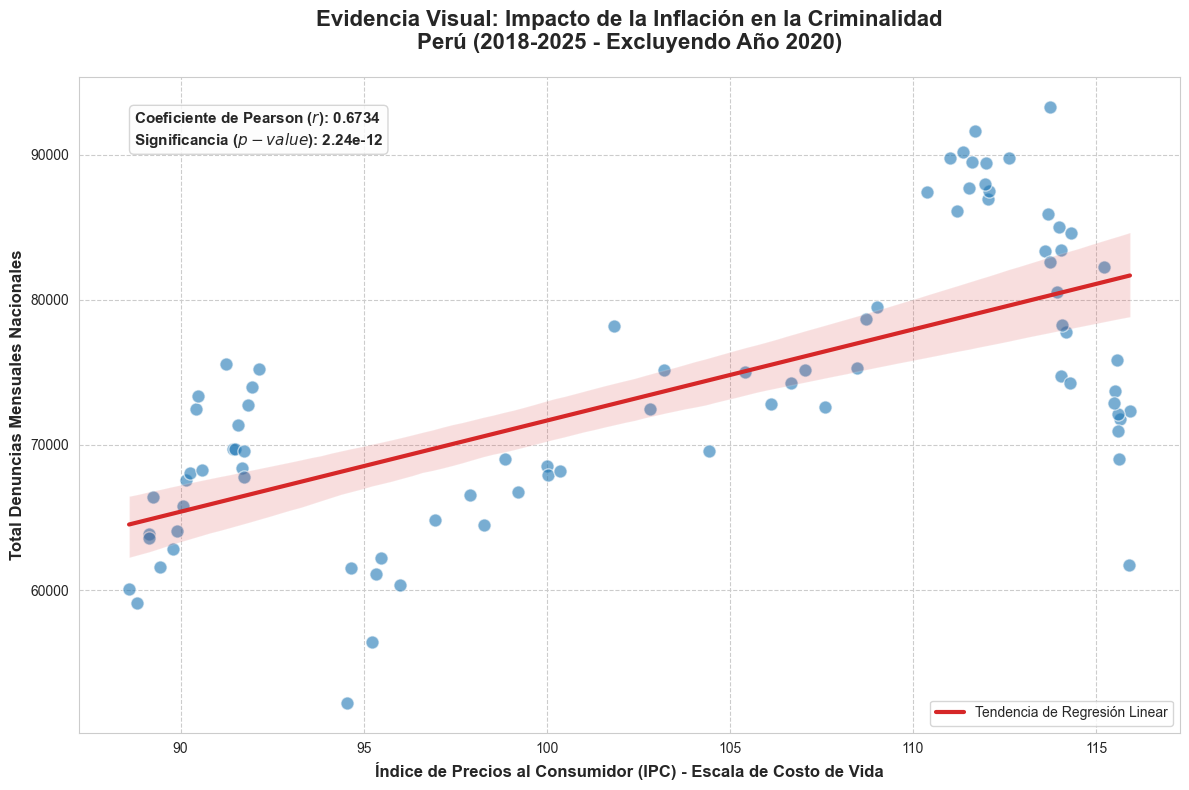

In [26]:
df_viz = df_nacional[df_nacional['fecha'].dt.year != 2020].copy()

sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
plt.figure(figsize=(12, 8))

chart = sns.regplot(data=df_viz, 
                    x='indice_precios', 
                    y='nro_denuncias', 
                    scatter_kws={'color': '#1f77b4', 'alpha': 0.6, 's': 90, 'edgecolor': 'w'}, 
                    line_kws={'color': '#d62728', 'lw': 3, 'label': 'Tendencia de Regresión Linear'},
                    ci=95) 

plt.title('Evidencia Visual: Impacto de la Inflación en la Criminalidad\nPerú (2018-2025 - Excluyendo Año 2020)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Índice de Precios al Consumidor (IPC) - Escala de Costo de Vida', fontsize=12, fontweight='bold')
plt.ylabel('Total Denuncias Mensuales Nacionales', fontsize=12, fontweight='bold')


text_stats = f'Coeficiente de Pearson ($r$): {r_ipc_s:.4f}\nSignificancia ($p-value$): {p_ipc_s:.2e}'
plt.gca().text(0.05, 0.95, text_stats, transform=plt.gca().transAxes,
                fontsize=11, fontweight='bold', verticalalignment='top',
                bbox=dict(boxstyle="round", fc="#fdfdfd", ec="#cccccc", alpha=0.8))

plt.legend(loc='lower right', frameon=True)

fig = chart.get_figure()
fig.tight_layout()
fig.savefig('../reports/02_scatter_regresion_final.png', dpi=300)
plt.show()

## 9. Exportación de Datos Procesados (Capa Gold)
Guardamos los resultados en formato Parquet para preservar los tipos de datos (especialmente las fechas) y asegurar una carga eficiente en el siguiente notebook de modelado.

In [ ]:
df_nacional.to_parquet('../data/gold_nacional_96m.parquet', index=False)

df.to_parquet('../data/gold_granular_clean.parquet', index=False)

print("Archivos guardados en /data!")

Archivos guardados en /data!
Formato: Parquet (Esquema preservado)
